In [1]:
!pip install -q langgraph langchain-core langchain-openai python-dotenv grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00


In [2]:
import os
from getpass import getpass

print("🔐 Enter your OpenAI API Key")
api_key = getpass("OpenAI API Key: ")

os.environ["OPENAI_API_KEY"] = api_key

🔐 Enter your OpenAI API Key
OpenAI API Key: ··········


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",  # or gpt-4o
    temperature=0.7
)

print("✅ OpenAI LLM Initialized")

✅ OpenAI LLM Initialized


### **WORKFLOW 1 — BASIC LINEAR FLOW**

In [4]:
from typing import TypedDict
from datetime import datetime
from langgraph.graph import StateGraph, START, END

class BasicState(TypedDict):
    topic: str
    research: str
    summary: str
    final_output: str


def research_node(state: BasicState):
    response = llm.invoke(f"Give 3 key facts about {state['topic']}")
    return {**state, "research": response.content}


def summarize_node(state: BasicState):
    response = llm.invoke(f"Summarize in 2 sentences: {state['research']}")
    return {**state, "summary": response.content}


def final_output_node(state: BasicState):
    return {
        **state,
        "final_output": f"""
📘 REPORT
Topic: {state['topic']}

Research:
{state['research']}

Summary:
{state['summary']}

Generated: {datetime.now()}
"""
    }


def create_basic_workflow():
    workflow = StateGraph(BasicState)

    workflow.add_node("research", research_node)
    workflow.add_node("summarize", summarize_node)
    workflow.add_node("final_output", final_output_node)

    workflow.add_edge(START, "research")
    workflow.add_edge("research", "summarize")
    workflow.add_edge("summarize", "final_output")
    workflow.add_edge("final_output", END)

    return workflow.compile()

In [5]:
basic_app = create_basic_workflow()

result = basic_app.invoke({
    "topic": "Artificial Intelligence",
    "research": "",
    "summary": "",
    "final_output": ""
})

print(result["final_output"])


📘 REPORT
Topic: Artificial Intelligence

Research:
Sure! Here are three key facts about Artificial Intelligence (AI):

1. **Types of AI**: AI can be categorized into three main types: Narrow AI, General AI, and Superintelligent AI. Narrow AI is designed to perform specific tasks (e.g., voice assistants, recommendation systems), General AI would possess the ability to understand and reason across a wide range of tasks like a human, and Superintelligent AI refers to a theoretical future AI that surpasses human intelligence in virtually all aspects.

2. **Machine Learning**: A significant subset of AI is machine learning (ML), which involves training algorithms on data to enable them to make predictions or decisions without explicit programming. ML techniques, such as supervised learning, unsupervised learning, and reinforcement learning, are widely used in applications ranging from image recognition to natural language processing.

3. **Ethical Considerations**: The rise of AI has raise

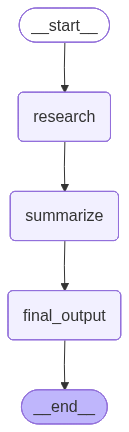

In [6]:
from IPython.display import Image

graph = basic_app.get_graph()
display(Image(graph.draw_mermaid_png()))

### **WORKFLOW 2 — PARALLEL PROCESSING**

In [7]:
class ParallelState(TypedDict):
    topic: str
    research: str
    creative: str
    analysis: str
    final_report: str


def research_node(state: ParallelState):
    res = llm.invoke(f"Research detailed facts about {state['topic']}")
    return {**state, "research": res.content}


def creative_node(state: ParallelState):
    res = llm.invoke(f"Write engaging content about {state['topic']}")
    return {**state, "creative": res.content}


def analysis_node(state: ParallelState):
    res = llm.invoke(f"Analyze pros, cons, and future of {state['topic']}")
    return {**state, "analysis": res.content}


def final_report_node(state: ParallelState):
    return {
        **state,
        "final_report": f"""
🌍 FINAL REPORT — {state['topic']}

Research:
{state['research'][:300]}

Creative:
{state['creative'][:300]}

Analysis:
{state['analysis'][:300]}
"""
    }


def create_parallel_workflow():
    workflow = StateGraph(ParallelState)

    workflow.add_node("research", research_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("analysis", analysis_node)
    workflow.add_node("final_report", final_report_node)

    workflow.add_edge(START, "research")
    workflow.add_edge("research", "creative")
    workflow.add_edge("research", "analysis")
    workflow.add_edge("creative", "final_report")
    workflow.add_edge("analysis", "final_report")
    workflow.add_edge("final_report", END)

    return workflow.compile()

In [8]:
parallel_app = create_parallel_workflow()

result = parallel_app.invoke({
    "topic": "Renewable Energy",
    "research": "",
    "creative": "",
    "analysis": "",
    "final_report": ""
})

print(result["final_report"])

InvalidUpdateError: At key 'topic': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

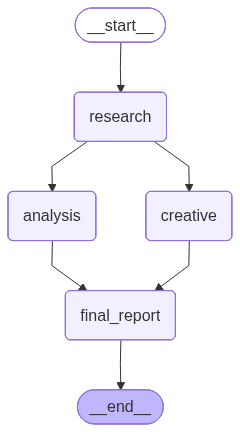

In [9]:
display(Image(parallel_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 3 — CONDITIONAL BRANCHING**

In [12]:
class ConditionalState(TypedDict):
    query: str
    query_type: str
    response: str


def classify_node(state: ConditionalState):
    res = llm.invoke(
        f"Classify this as technical, creative, or general: {state['query']}"
    )
    return {**state, "query_type": res.content.strip().lower()}


def technical_node(state):
    res = llm.invoke(f"Provide detailed technical answer: {state['query']}")
    return {**state, "response": res.content}


def creative_node(state):
    res = llm.invoke(f"Provide creative response: {state['query']}")
    return {**state, "response": res.content}


def general_node(state):
    res = llm.invoke(f"Provide clear explanation: {state['query']}")
    return {**state, "response": res.content}


def route(state: ConditionalState):
    if "technical" in state["query_type"]:
        return "technical"
    elif "creative" in state["query_type"]:
        return "creative"
    else:
        return "general"


def create_conditional_workflow():
    workflow = StateGraph(ConditionalState)

    workflow.add_node("classify", classify_node)
    workflow.add_node("technical", technical_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("general", general_node)

    workflow.add_edge(START, "classify")

    workflow.add_conditional_edges(
        "classify",
        route,
        {
            "technical": "technical",
            "creative": "creative",
            "general": "general"
        }
    )

    workflow.add_edge("technical", END)
    workflow.add_edge("creative", END)
    workflow.add_edge("general", END)

    return workflow.compile()

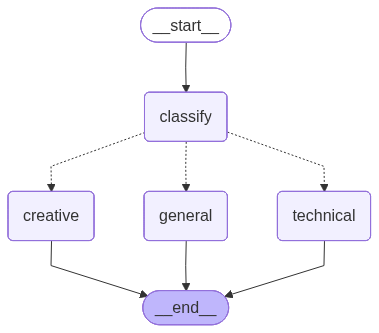

In [13]:
conditional_app = create_conditional_workflow()
display(Image(conditional_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 4 — LOOP / SELF-IMPROVING AGENT**

In [14]:
class LoopState(TypedDict):
    query: str
    response: str
    score: int
    iteration: int


def generate_node(state: LoopState):
    res = llm.invoke(f"Answer: {state['query']}")
    return {**state, "response": res.content, "iteration": state["iteration"] + 1}


def evaluate_node(state: LoopState):
    res = llm.invoke(
        f"Score this answer 1-5 only:\n{state['response']}"
    )
    try:
        score = int(res.content.strip()[0])
    except:
        score = 3
    return {**state, "score": score}


def route_loop(state: LoopState):
    if state["score"] < 4 and state["iteration"] < 3:
        return "generate"
    return "end"


def create_loop_workflow():
    workflow = StateGraph(LoopState)

    workflow.add_node("generate", generate_node)
    workflow.add_node("evaluate", evaluate_node)

    workflow.add_edge(START, "generate")
    workflow.add_edge("generate", "evaluate")

    workflow.add_conditional_edges(
        "evaluate",
        route_loop,
        {
            "generate": "generate",
            "end": END
        }
    )

    return workflow.compile()

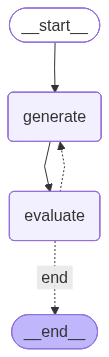

In [16]:
loop_app = create_loop_workflow()
display(Image(loop_app.get_graph().draw_mermaid_png()))